## **Retail Sales Data Analysis Project**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1) (1).zip


In [3]:
import os
os.listdir('dataset_folder')

FileNotFoundError: [Errno 2] No such file or directory: 'dataset_folder'

In [4]:
import zipfile
import os

# Get the name of the uploaded zip file
zip_file_name = list(uploaded.keys())[0]

# Create a directory to extract the dataset into
dataset_dir = 'dataset_folder'
os.makedirs(dataset_dir, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

print(f"Successfully extracted '{zip_file_name}' to '{dataset_dir}'")

# Now list the contents of the newly created directory
print(f"Contents of '{dataset_dir}':")
print(os.listdir(dataset_dir))

Successfully extracted 'archive (1) (1).zip' to 'dataset_folder'
Contents of 'dataset_folder':
['retail_sales_dataset.csv']


In [5]:
import os
os.listdir('dataset_folder')

['retail_sales_dataset.csv']

# Dataset Overview

In [6]:
import pandas as pd

df = pd.read_csv('dataset_folder/retail_sales_dataset.csv')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


# Data Cleaning

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


# Exploratory Data Analysis

In [8]:
df.isnull().sum()



,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [9]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [10]:
df['Total Amount'].sum()

np.int64(456000)

In [11]:
df.groupby('Product Category')['Total Amount'].sum()

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


In [12]:
df.groupby('Gender')['Total Amount'].sum()

,Total Amount
Gender,
Female,232840
Male,223160


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizations and Insights

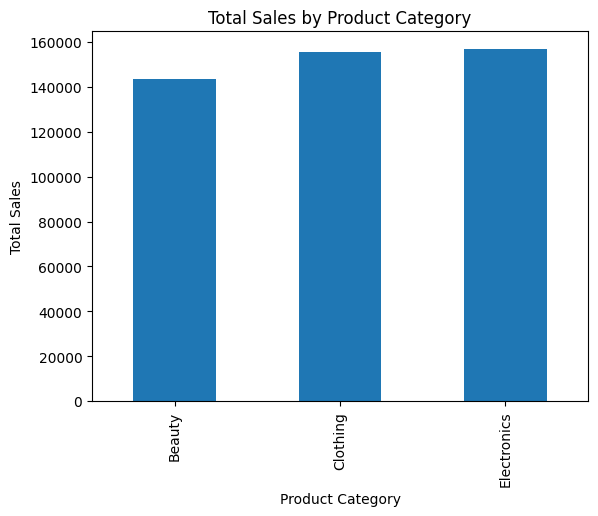

In [15]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

category_sales.plot(kind='bar')
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()

Insight:
Among all product categories, the category with the highest total sales generated the most revenue, indicating stronger customer demand and better market performance. This suggests that the business should focus more on promoting and expanding this category to maximize profits. Lower-performing categories may require improved marketing strategies, discounts, or product enhancements to increase sales.

# Visualizations and Insights

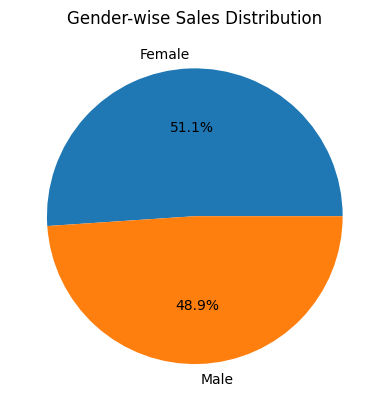

In [16]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender-wise Sales Distribution")
plt.ylabel("")
plt.show()

Insight:
Gender-wise sales analysis shows which customer group contributes more to total revenue. The higher-spending gender represents a stronger target market for the business. This information can help companies create more personalized marketing strategies, improve product targeting, and maximize customer engagement.

In [17]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

# Visualizations and Insights

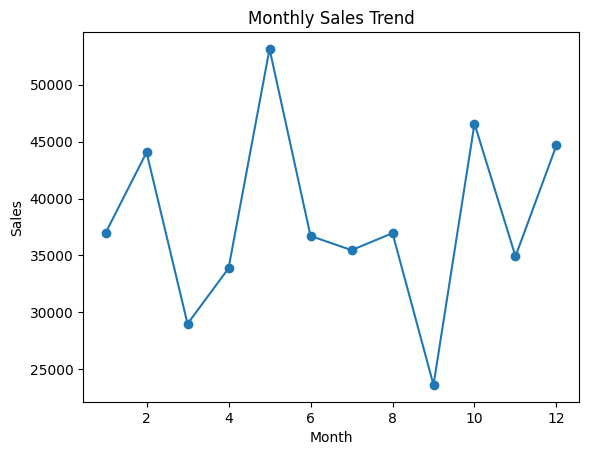

In [18]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Insight:
Monthly sales analysis helps identify seasonal trends, peak sales periods, and low-performing months. The month with the highest sales indicates stronger customer purchasing activity, while lower sales months may require promotional campaigns or discounts to improve performance. Understanding these trends helps businesses optimize inventory, marketing, and sales strategies.

# Visualizations and Insights

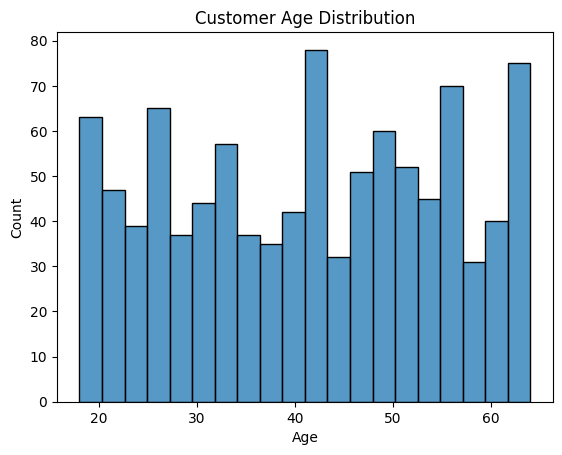

In [19]:
sns.histplot(df['Age'], bins=20)
plt.title("Customer Age Distribution")
plt.show()

Insight:
Customer age distribution analysis helps identify the primary age group contributing to sales. The most frequent customer age range represents the core target audience for the business. Understanding customer demographics allows companies to design age-specific marketing strategies, product recommendations, and promotional campaigns.

In [ ]:
Conclusion:
This project analyzed retail sales data to identify customer behavior, product performance, and revenue trends. The analysis revealed key sales drivers across product categories, gender groups, monthly trends, and customer demographics. These findings can help businesses make data-driven decisions, improve marketing strategies, and optimize product offerings for better profitability.